# Logistics Operations Analysis

## Objective
This analysis focuses on identifying whether performance differences are driven by individual drivers or by standardized operational processes.

## Key Questions
- Is workload evenly distributed across drivers?
- Does experience impact performance?
- Are there differences in efficiency (MPG)?

## Data Source

Synthetic Logistics Operations Database (Kaggle)

The dataset contains operational data including drivers, trips, fuel usage, and performance metrics across a 3-year period.

## Data Loading and Setup

In [3]:
#use python to install kaggle, pandas, duckdb
!pip install kagglehub pandas duckdb

In [4]:
#download dataset
import kagglehub

path = kagglehub.dataset_download("yogape/logistics-operations-database")

print("Dataset path:", path)

Dataset path: C:\Users\scros\.cache\kagglehub\datasets\yogape\logistics-operations-database\versions\1


In [5]:
#take a gander inside the folder
import os

print(os.listdir(path))

['customers.csv', 'DATABASE_SCHEMA.txt', 'delivery_events.csv', 'drivers.csv', 'driver_monthly_metrics.csv', 'facilities.csv', 'fuel_purchases.csv', 'loads.csv', 'maintenance_records.csv', 'routes.csv', 'safety_incidents.csv', 'trailers.csv', 'trips.csv', 'trucks.csv', 'truck_utilization_metrics.csv']


In [6]:
#import pandas and OS
import pandas as pd
import os

## Initial Data Exploration

In [7]:
#load drivers table
import pandas as pd
import os

drivers = pd.read_csv(os.path.join(path, "drivers.csv"))

drivers.head()

,driver_id,first_name,last_name,hire_date,termination_date,license_number,license_state,date_of_birth,home_terminal,employment_status,cdl_class,years_experience
0,DRV00001,Jennifer,Hernandez,2014-10-31,NaN,DL673510887,WA,1973-11-07,Denver,Active,A,3
1,DRV00002,William,Martin,2020-10-02,NaN,DL128955006,GA,1976-11-03,Columbus,Active,A,20
2,DRV00003,Charles,Hernandez,2021-09-21,NaN,DL523076025,NC,1970-04-06,Salt Lake City,Active,A,19
3,DRV00004,Barbara,Brown,2013-09-08,NaN,DL735540030,WA,1995-02-06,Denver,Active,A,19
4,DRV00005,Mary,Martinez,2018-12-02,NaN,DL706011277,AZ,1960-07-15,Chicago,Active,A,12


In [8]:
#view strucutre of drivers table
drivers.columns

Index(['driver_id', 'first_name', 'last_name', 'hire_date', 'termination_date',
       'license_number', 'license_state', 'date_of_birth', 'home_terminal',
       'employment_status', 'cdl_class', 'years_experience'],
      dtype='object')

In [9]:
#view shape of table
drivers.shape

(150, 12)

In [10]:
#inspect columns in drivers table
drivers.dtypes

driver_id            object
first_name           object
last_name            object
hire_date            object
termination_date     object
license_number       object
license_state        object
date_of_birth        object
home_terminal        object
employment_status    object
cdl_class            object
years_experience      int64
dtype: object

In [11]:
#load trips table
trips = pd.read_csv(os.path.join(path, "trips.csv"))

trips.head()

,trip_id,load_id,driver_id,truck_id,trailer_id,dispatch_date,actual_distance_miles,actual_duration_hours,fuel_gallons_used,average_mpg,idle_time_hours,trip_status
0,TRIP00000001,LOAD00000001,DRV00117,TRK00035,TRL00167,2022-01-01,1314,26.2,183.8,7.15,3.5,Completed
1,TRIP00000002,LOAD00000002,DRV00141,TRK00108,TRL00082,2022-01-01,515,8.6,93.6,5.50,8.3,Completed
2,TRIP00000003,LOAD00000003,DRV00032,TRK00031,TRL00138,2022-01-01,2509,45.0,339.1,7.40,12.0,Completed
3,TRIP00000004,LOAD00000004,DRV00083,TRK00105,TRL00018,2022-01-01,717,11.1,110.3,6.50,9.6,Completed
4,TRIP00000005,LOAD00000005,DRV00044,TRK00076,TRL00054,2022-01-01,2243,35.0,328.9,6.82,11.6,Completed


In [12]:
#view structure of trips table
trips.columns

Index(['trip_id', 'load_id', 'driver_id', 'truck_id', 'trailer_id',
       'dispatch_date', 'actual_distance_miles', 'actual_duration_hours',
       'fuel_gallons_used', 'average_mpg', 'idle_time_hours', 'trip_status'],
      dtype='object')

In [13]:
#Inspect columns in trips table
trips.dtypes

trip_id                   object
load_id                   object
driver_id                 object
truck_id                  object
trailer_id                object
dispatch_date             object
actual_distance_miles      int64
actual_duration_hours    float64
fuel_gallons_used        float64
average_mpg              float64
idle_time_hours          float64
trip_status               object
dtype: object

In [14]:
#import duckdb
import duckdb

con = duckdb.connect()

con.register("drivers", drivers)
con.register("trips", trips)

## Driver Performance (Trip Volume)

In [15]:
#count trips per driver
query = """
SELECT
    driver_id,
    COUNT(*) AS trip_count
FROM trips
GROUP BY driver_id
ORDER BY trip_count DESC
"""

In [16]:
#execute query
top_drivers = con.execute(query).df()
top_drivers

,driver_id,trip_count
0,None,1714
1,DRV00019,749
2,DRV00066,737
3,DRV00108,735
4,DRV00059,729
...,...,...
120,DRV00080,614
121,DRV00064,610
122,DRV00012,608
123,DRV00091,607


In [17]:
#join drivers table
query = """
SELECT
    t.driver_id,
    d.first_name,
    d.last_name,
    COUNT(*) AS trip_count
FROM trips t
LEFT JOIN drivers d
    ON t.driver_id = d.driver_id
GROUP BY
    t.driver_id,
    d.first_name,
    d.last_name
ORDER BY trip_count DESC
"""

In [18]:
#execute query
top_drivers = con.execute(query).df()
top_drivers

,driver_id,first_name,last_name,trip_count
0,None,None,None,1714
1,DRV00019,Robert,Jackson,749
2,DRV00066,William,Wilson,737
3,DRV00108,Joseph,Jones,735
4,DRV00059,Barbara,Gonzalez,729
...,...,...,...,...
120,DRV00080,Richard,Martin,614
121,DRV00064,Michael,Smith,610
122,DRV00012,Robert,Moore,608
123,DRV00091,Linda,Rodriguez,607


In [19]:
#how many drivers ids are na
trips["driver_id"].isna().sum()

np.int64(1714)

In [20]:
#how many driver id's are blank stings
trips["driver_id"].eq("").sum()

np.int64(0)

In [21]:
#unmatched trip rows
query = """
SELECT
    COUNT(*) AS unmatched_trip_rows
FROM trips t
LEFT JOIN drivers d
    ON t.driver_id = d.driver_id
WHERE d.driver_id IS NULL
"""
unmatched = con.execute(query).df()
unmatched

,unmatched_trip_rows
0,1714


In [22]:
#inspect the examples
query = """
SELECT
    t.trip_id,
    t.driver_id
FROM trips t
LEFT JOIN drivers d
    ON t.driver_id = d.driver_id
WHERE d.driver_id IS NULL
"""
bad_rows = con.execute(query).df()
bad_rows

,trip_id,driver_id
0,TRIP00000067,None
1,TRIP00000104,None
2,TRIP00000257,None
3,TRIP00000415,None
4,TRIP00000438,None
...,...,...
1709,TRIP00085125,None
1710,TRIP00085147,None
1711,TRIP00085240,None
1712,TRIP00085249,None


In [23]:
#filter out null drivers
query = """
SELECT
    t.driver_id,
    d.first_name,
    d.last_name,
    COUNT(*) AS trip_count
FROM trips t
LEFT JOIN drivers d
    ON t.driver_id = d.driver_id
WHERE t.driver_id IS NOT NULL
GROUP BY
    t.driver_id,
    d.first_name,
    d.last_name
ORDER BY trip_count DESC
"""

In [24]:
query = """
SELECT
    COUNT(*) AS total_trips,
    SUM(CASE WHEN driver_id IS NULL THEN 1 ELSE 0 END) AS unassigned_trips
FROM trips
"""

In [25]:
#run query with nulls removed
driver_trip_counts = con.execute(query).df()
driver_trip_counts

,total_trips,unassigned_trips
0,85410,1714.0


### Key Finding
Trip counts are relatively consistent across drivers with no extreme outliers.

## Distance-Based Performance

In [26]:
#calculate total miles

query = """
SELECT
    t.driver_id,
    d.first_name,
    d.last_name,
    COUNT(*) AS trip_count,
    SUM(t.actual_distance_miles) AS total_miles
FROM trips t
LEFT JOIN drivers d
    ON t.driver_id = d.driver_id
WHERE t.driver_id IS NOT NULL
GROUP BY
    t.driver_id,
    d.first_name,
    d.last_name
ORDER BY total_miles DESC
"""

In [27]:
driver_distance = con.execute(query).df()
driver_distance

,driver_id,first_name,last_name,trip_count,total_miles
0,DRV00051,Linda,Davis,723,1074677.0
1,DRV00108,Joseph,Jones,735,1073445.0
2,DRV00059,Barbara,Gonzalez,729,1064844.0
3,DRV00019,Robert,Jackson,749,1060268.0
4,DRV00149,Linda,Jones,721,1059718.0
...,...,...,...,...,...
119,DRV00064,Michael,Smith,610,874646.0
120,DRV00122,James,Wilson,604,874195.0
121,DRV00080,Richard,Martin,614,858414.0
122,DRV00091,Linda,Rodriguez,607,855939.0


In [28]:
#calculate average miles per trip
query = """
SELECT
    t.driver_id,
    d.first_name,
    d.last_name,
    COUNT(*) AS trip_count,
    SUM(t.actual_distance_miles) AS total_miles,
    AVG(t.actual_distance_miles) AS avg_miles_per_trip
FROM trips t
LEFT JOIN drivers d
    ON t.driver_id = d.driver_id
WHERE t.driver_id IS NOT NULL
GROUP BY
    t.driver_id,
    d.first_name,
    d.last_name
ORDER BY avg_miles_per_trip DESC
"""

In [29]:
driver_efficiency = con.execute(query).df()
driver_efficiency

,driver_id,first_name,last_name,trip_count,total_miles,avg_miles_per_trip
0,DRV00102,Elizabeth,Rodriguez,634,947360.0,1494.258675
1,DRV00003,Charles,Hernandez,677,1010235.0,1492.223043
2,DRV00127,Thomas,Gonzalez,702,1047108.0,1491.606838
3,DRV00004,Barbara,Brown,659,982625.0,1491.084977
4,DRV00026,Charles,Miller,666,991294.0,1488.429429
...,...,...,...,...,...,...
119,DRV00124,Thomas,Jackson,702,970839.0,1382.961538
120,DRV00150,Robert,Martin,706,973942.0,1379.521246
121,DRV00012,Robert,Moore,608,836187.0,1375.307566
122,DRV00097,Thomas,Rodriguez,683,933681.0,1367.029283


In [30]:
#trip count vs avg miles order by trip count
query = """
SELECT
    t.driver_id,
    COUNT(*) AS trip_count,
    AVG(t.actual_distance_miles) AS avg_miles_per_trip
FROM trips t
WHERE t.driver_id IS NOT NULL
GROUP BY t.driver_id
ORDER BY trip_count DESC
"""

In [31]:
trip_vs_distance = con.execute(query).df()
trip_vs_distance

,driver_id,trip_count,avg_miles_per_trip
0,DRV00019,749,1415.578104
1,DRV00066,737,1366.750339
2,DRV00108,735,1460.469388
3,DRV00059,729,1460.691358
4,DRV00087,725,1420.155862
...,...,...,...
119,DRV00080,614,1398.068404
120,DRV00064,610,1433.845902
121,DRV00012,608,1375.307566
122,DRV00091,607,1410.113674


In [32]:
#trip count vs avg miles order by avg miles
query = """
SELECT
    t.driver_id,
    COUNT(*) AS trip_count,
    AVG(t.actual_distance_miles) AS avg_miles_per_trip
FROM trips t
WHERE t.driver_id IS NOT NULL
GROUP BY t.driver_id
ORDER BY avg_miles_per_trip DESC
"""
trip_vs_distance = con.execute(query).df()
trip_vs_distance

,driver_id,trip_count,avg_miles_per_trip
0,DRV00102,634,1494.258675
1,DRV00003,677,1492.223043
2,DRV00127,702,1491.606838
3,DRV00004,659,1491.084977
4,DRV00026,666,1488.429429
...,...,...,...
119,DRV00124,702,1382.961538
120,DRV00150,706,1379.521246
121,DRV00012,608,1375.307566
122,DRV00097,683,1367.029283


### Key Finding
Variation in total miles is driven by trip length rather than number of trips.

In [33]:
#feul usage 
query = """
SELECT
    t.driver_id,
    d.first_name,
    d.last_name,
    COUNT(*) AS trip_count,
    SUM(t.actual_distance_miles) AS total_miles,
    SUM(t.fuel_gallons_used) AS total_fuel,
    SUM(t.actual_distance_miles) / SUM(t.fuel_gallons_used) AS miles_per_gallon
FROM trips t
LEFT JOIN drivers d
    ON t.driver_id = d.driver_id
WHERE t.driver_id IS NOT NULL
GROUP BY
    t.driver_id,
    d.first_name,
    d.last_name
ORDER BY miles_per_gallon DESC
"""
driver_efficiency = con.execute(query).df()
driver_efficiency

,driver_id,first_name,last_name,trip_count,total_miles,total_fuel,miles_per_gallon
0,DRV00109,Joseph,Davis,657,953178.0,145845.3,6.535541
1,DRV00061,Linda,Gonzalez,678,939390.0,144240.8,6.512651
2,DRV00105,Barbara,Moore,679,973771.0,149548.6,6.511402
3,DRV00039,Thomas,Martinez,682,965658.0,148559.9,6.500126
4,DRV00057,Thomas,Jackson,635,911374.0,140223.0,6.499462
...,...,...,...,...,...,...,...
119,DRV00150,Robert,Martin,706,973942.0,152060.7,6.404955
120,DRV00033,William,Anderson,666,958305.0,149620.1,6.404922
121,DRV00114,Thomas,Wilson,698,1023278.0,159819.0,6.402731
122,DRV00130,Karen,Lopez,701,973944.0,152574.7,6.383391


## Fuel Efficiency Analysis

In [34]:
#add in type of truck (did not tell me anything would need another table and a better understanding of trucks)
query = """
SELECT
    t.driver_id,
    d.first_name,
    d.last_name,
    t.truck_id,
    COUNT(*) AS trip_count,
    SUM(t.actual_distance_miles) AS total_miles,
    SUM(t.fuel_gallons_used) AS total_fuel,
    SUM(t.actual_distance_miles) / SUM(t.fuel_gallons_used) AS miles_per_gallon
FROM trips t
LEFT JOIN drivers d
    ON t.driver_id = d.driver_id
WHERE t.driver_id IS NOT NULL
GROUP BY
    t.driver_id,
    d.first_name,
    d.last_name,
    t.truck_id
ORDER BY miles_per_gallon DESC
"""
driver_efficiency = con.execute(query).df()
driver_efficiency

,driver_id,first_name,last_name,truck_id,trip_count,total_miles,total_fuel,miles_per_gallon
0,DRV00088,Joseph,Garcia,TRK00093,1,1354.0,180.5,7.501385
1,DRV00022,Charles,Moore,TRK00072,2,3968.0,530.8,7.475509
2,DRV00111,Richard,Jones,TRK00113,1,1256.0,168.1,7.471743
3,DRV00109,Joseph,Davis,TRK00120,2,3877.0,519.7,7.460073
4,DRV00074,William,Brown,TRK00030,2,2729.0,367.0,7.435967
...,...,...,...,...,...,...,...,...
11516,DRV00100,Jennifer,Martinez,TRK00041,2,1357.0,239.7,5.661243
11517,DRV00032,Michael,Anderson,TRK00090,5,6841.0,1214.1,5.634626
11518,DRV00120,Jessica,Johnson,TRK00086,1,2731.0,485.1,5.629767
11519,DRV00090,David,Anderson,TRK00050,1,2072.0,370.7,5.589425


### Key Finding
Fuel efficiency is tightly clustered (~6.37–6.53 MPG), indicating minimal variation across drivers.

## Experience vs Performance

In [35]:
#Does experience matter for feul efficiency
query = """
SELECT
    t.driver_id,
    d.first_name,
    d.last_name,
    d.years_experience,
    COUNT(*) AS trip_count,
    SUM(t.actual_distance_miles) AS total_miles,
    SUM(t.actual_distance_miles) / SUM(t.fuel_gallons_used) AS miles_per_gallon
FROM trips t
LEFT JOIN drivers d
    ON t.driver_id = d.driver_id
WHERE t.driver_id IS NOT NULL
GROUP BY
    t.driver_id,
    d.first_name,
    d.last_name,
    d.years_experience
ORDER BY d.years_experience DESC
"""
driver_efficiency = con.execute(query).df()
driver_efficiency

,driver_id,first_name,last_name,years_experience,trip_count,total_miles,miles_per_gallon
0,DRV00012,Robert,Moore,25,608,836187.0,6.437323
1,DRV00061,Linda,Gonzalez,25,678,939390.0,6.512651
2,DRV00126,Sarah,Jackson,25,671,951167.0,6.432058
3,DRV00065,Robert,Brown,25,670,973873.0,6.462226
4,DRV00075,John,Anderson,25,649,926107.0,6.440839
...,...,...,...,...,...,...,...
119,DRV00063,James,Jones,2,697,980005.0,6.452687
120,DRV00124,Thomas,Jackson,2,702,970839.0,6.458710
121,DRV00143,Linda,Smith,2,668,975719.0,6.446427
122,DRV00041,Karen,Martin,2,657,918455.0,6.405736


In [36]:
#group by experience 
query = """
SELECT
    d.years_experience,
    COUNT(DISTINCT t.driver_id) AS driver_count,
    AVG(t.actual_distance_miles) AS avg_trip_distance,
    AVG(t.fuel_gallons_used) AS avg_fuel,
    AVG(t.actual_distance_miles) / AVG(t.fuel_gallons_used) AS avg_mpg
FROM trips t
LEFT JOIN drivers d
    ON t.driver_id = d.driver_id
WHERE t.driver_id IS NOT NULL
GROUP BY d.years_experience
ORDER BY d.years_experience
"""
driver_efficiency = con.execute(query).df()
driver_efficiency

,years_experience,driver_count,avg_trip_distance,avg_fuel,avg_mpg
0,2,5,1408.072296,218.585304,6.441752
1,3,7,1438.150619,223.365703,6.438547
2,4,5,1434.703955,222.130490,6.458834
3,5,6,1447.426750,224.746025,6.440277
4,6,6,1428.168371,221.397032,6.450711
5,7,4,1441.913762,223.082429,6.463592
6,8,1,1435.667178,222.041104,6.465772
7,9,4,1430.897136,222.585946,6.428515
8,10,4,1406.212190,217.909707,6.453187
9,11,8,1434.900803,222.041976,6.462295


In [37]:
#compute simple corralation 
query = """
SELECT
    t.driver_id,
    d.years_experience,
    SUM(t.actual_distance_miles) / SUM(t.fuel_gallons_used) AS mpg
FROM trips t
LEFT JOIN drivers d
    ON t.driver_id = d.driver_id
WHERE t.driver_id IS NOT NULL
GROUP BY t.driver_id, d.years_experience
"""
df = con.execute(query).df()

df["years_experience"].corr(df["mpg"])

np.float64(0.10435864057879007)

### Key Finding
Correlation between experience and MPG is weak (~0.10), indicating no meaningful relationship.

## Workload Distribution

In [38]:
#do experienced drivers get more work
query = """
SELECT
    d.years_experience,
    COUNT(DISTINCT t.driver_id) AS driver_count,
    AVG(t.actual_distance_miles) AS avg_trip_distance,
    COUNT(t.trip_id) AS total_trips
FROM trips t
LEFT JOIN drivers d
    ON t.driver_id = d.driver_id
WHERE t.driver_id IS NOT NULL
GROUP BY d.years_experience
ORDER BY d.years_experience
"""
driver_efficiency = con.execute(query).df()
driver_efficiency

,years_experience,driver_count,avg_trip_distance,total_trips
0,2,5,1408.072296,3375
1,3,7,1438.150619,4601
2,4,5,1434.703955,3388
3,5,6,1447.426750,4000
4,6,6,1428.168371,4009
5,7,4,1441.913762,2783
6,8,1,1435.667178,652
7,9,4,1430.897136,2654
8,10,4,1406.212190,2658
9,11,8,1434.900803,5353


In [39]:
#workload spread
query = """
SELECT
    t.driver_id,
    d.first_name,
    d.last_name,
    SUM(t.actual_distance_miles) AS total_miles,
    COUNT(*) AS trip_count
FROM trips t
LEFT JOIN drivers d
    ON t.driver_id = d.driver_id
WHERE t.driver_id IS NOT NULL
GROUP BY
    t.driver_id,
    d.first_name,
    d.last_name
ORDER BY total_miles DESC
"""
driver_efficiency = con.execute(query).df()
driver_efficiency

,driver_id,first_name,last_name,total_miles,trip_count
0,DRV00051,Linda,Davis,1074677.0,723
1,DRV00108,Joseph,Jones,1073445.0,735
2,DRV00059,Barbara,Gonzalez,1064844.0,729
3,DRV00019,Robert,Jackson,1060268.0,749
4,DRV00149,Linda,Jones,1059718.0,721
...,...,...,...,...,...
119,DRV00064,Michael,Smith,874646.0,610
120,DRV00122,James,Wilson,874195.0,604
121,DRV00080,Richard,Martin,858414.0,614
122,DRV00091,Linda,Rodriguez,855939.0,607


In [40]:
#workload concentrated among a subset of drivers?
query = """
SELECT
    t.driver_id,
    SUM(t.actual_distance_miles) AS total_miles
FROM trips t
WHERE t.driver_id IS NOT NULL
GROUP BY t.driver_id
ORDER BY total_miles DESC
"""
df = con.execute(query).df()

In [41]:
df["total_miles"].describe()

count    1.240000e+02
mean     9.652605e+05
std      4.770083e+04
min      8.361870e+05
25%      9.334428e+05
50%      9.703950e+05
75%      9.993670e+05
max      1.074677e+06
Name: total_miles, dtype: float64

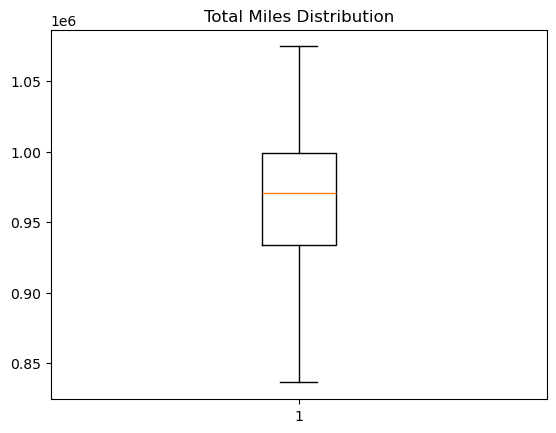

In [42]:
## Boxplot to assess distribution of total miles across drivers (checking for variability and outliers)
import matplotlib.pyplot as plt

plt.boxplot(df["total_miles"])
plt.title("Total Miles Distribution")
plt.show()

### Key Finding
Workload is evenly distributed across drivers with no significant outliers.

## Conclusion

Results indicate that:
- Workload is evenly distributed across drivers
- Performance metrics are consistent across the fleet
- Experience does not significantly influence efficiency or workload

These findings suggest operations are highly standardized, with outcomes driven by system-level processes rather than individual driver differences.

## Data Export for Visualization

The final dataset used for visualization was exported from the analysis environment.  
This dataset contains aggregated driver performance metrics and is used for building a Power BI dashboard.

In [43]:
driver_distance.to_csv("driver_distance.csv", index=False)

In [47]:
query = """
SELECT
    t.trip_id,
    t.driver_id,
    d.first_name,
    d.last_name,
    d.first_name || ' ' || d.last_name AS full_name,
    d.years_experience,
    d.license_state,
    d.home_terminal,
    t.dispatch_date,
    t.actual_distance_miles,
    t.fuel_gallons_used
FROM trips t
LEFT JOIN drivers d
    ON t.driver_id = d.driver_id
WHERE t.driver_id IS NOT NULL
  AND t.dispatch_date >= '2023-01-01'
  AND t.dispatch_date < '2024-01-01'
"""

In [48]:
trips_2023_enriched = con.execute(query).df()
trips_2023_enriched.to_csv("trips_2023_enriched.csv", index=False)